
## Часть 2. Использование модели

**Цель:** отработать навыки адаптации готовых моделей для решения прикладной задачи на русском языке, а также создание небольших демо для задач.



### [2 балла] Добавить модель переводчика

У вас уже есть готовая модель, которая может по картинке отвечать на текстовые запросы к картинке. Ваша цель — обобщить эту модель на русский язык, добавив модель переводчик, которая будет переводить запрос на русском языке в запрос на английском языке и передавать его модели. За основу вы можете взять языковую модель (например, https://huggingface.co/Helsinki-NLP/opus-mt-ru-en). Альтернативой может стать реализация функции, делающий api вызов, к приложению переводчика (например, https://libretranslate.com/).

---

**Ожидаемый результат.** В качестве результата в этой секции вам нужно предоставить функции, которые делают перевод с русского на английского и делает инференс модели DocVQA и выводит ответ на русском языке. (В качестве примеров вопросов, можете использовать данные из датасета).


Нам нужно реализовать вот такой пайплайн:

Русский вопрос >> [Перевод RU-EN] >> [DocVQA модель] >> Английский ответ >> [Перевод EN-RU] >> Русский ответ

In [ ]:
import os
from transformers import AutoModelForDocumentQuestionAnswering, AutoProcessor

model_dir = "~/project/ml-modern/homework/hw03/model"
# The model was saved in a checkpoint subdirectory by the Trainer
model_path = os.path.expanduser(
    model_dir + "/layoutlmv2-base-uncased_finetuned_docvqa/checkpoint-200"
)

# Загружаем модель из ДЗ-3 Часть 1
docvqa_model = AutoModelForDocumentQuestionAnswering.from_pretrained(model_path)

# Load the processor (tokenizer + image processor)
docvqa_processor = AutoProcessor.from_pretrained(model_path)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Загружаем модель для перевода с английского на русский
opus_ru_en_tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-ru-en")
opus_ru_en_model = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-ru-en")

# Загружаем модель для перевода с английского на русский
opus_en_ru_tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-ru")
opus_en_ru_model = AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-en-ru")


/home/lev/.cache/uv/virtualenvs/ml-modern-hw03/lib/python3.12/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [25]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
from PIL import Image


def translate_en2ru(text):
    # Токенизируем входной текст
    inputs = opus_en_ru_tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    
    # Генерируем перевод
    translated_tokens = opus_en_ru_model.generate(**inputs, max_length=512)
    
    # Декодируем результат
    translated_text = opus_en_ru_tokenizer.batch_decode(translated_tokens, skip_special_tokens=True)[0]
    
    return translated_text

def translate_ru2en(text):
    # Используем уже загруженную модель opus-mt-ru-en
    # Токенизируем входной текст
    inputs = opus_ru_en_tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    
    # Генерируем перевод
    translated_tokens = opus_ru_en_model.generate(**inputs, max_length=512)
    
    # Декодируем результат
    translated_text = opus_ru_en_tokenizer.batch_decode(translated_tokens, skip_special_tokens=True)[0]
    
    return translated_text

# Нам нужно реализовать вот такой пайплайн:
#   Русский вопрос >> [Перевод RU-EN] >> [DocVQA модель] >> Английский ответ 
#   >> [Перевод EN-RU] >> Русский ответ
def ru_inference(image, question_ru, debug=False):
    # Ensure image is in PIL format
    if isinstance(image, str):
        image = Image.open(image)

    # Convert image to RGB if needed
    if image.mode != "RGB":
        image = image.convert("RGB")

    # Step 1: Translate Russian question to English
    question_en = translate_ru2en(question_ru)
    print(f"Question (RU): {question_ru}")
    print(f"Question (EN): {question_en}")

    # Step 2: Encode the image and English question
    encoding = docvqa_processor(image, question_en, return_tensors="pt")

    # Step 3: Run inference with DocVQA model
    with torch.no_grad():
        outputs = docvqa_model(**encoding)

    # Step 4: Extract answer from model outputs
    # Get the start and end logits for the answer span
    start_logits = outputs.start_logits
    end_logits = outputs.end_logits

    # Find the most likely start and end positions
    predicted_start_idx = start_logits.argmax(-1).item()
    predicted_end_idx = end_logits.argmax(-1).item()

    if debug:
        print(f"Predicted start_idx: {predicted_start_idx}, end_idx: {predicted_end_idx}")
        print(f"Start token: {docvqa_processor.tokenizer.decode([encoding.input_ids[0][predicted_start_idx]])}")
        print(f"End token: {docvqa_processor.tokenizer.decode([encoding.input_ids[0][predicted_end_idx]])}")

    # Fix 1: Handle start > end (swap them)
    if predicted_end_idx < predicted_start_idx:
        if debug:
            print(f"Swapping indices: start {predicted_start_idx} > end {predicted_end_idx}")
        predicted_end_idx = predicted_start_idx

    # Decode the answer tokens to get the English answer
    answer_en = docvqa_processor.tokenizer.decode(
        encoding.input_ids.squeeze()[predicted_start_idx : predicted_end_idx + 1],
        skip_special_tokens=True
    ).strip()

    # Fix 2: Check if answer is empty or consists of special tokens
    if not answer_en:
        # Check if we're pointing to special tokens
        token_id = encoding.input_ids[0][predicted_start_idx].item()
        if token_id in [docvqa_processor.tokenizer.cls_token_id, 
                        docvqa_processor.tokenizer.sep_token_id,
                        docvqa_processor.tokenizer.pad_token_id]:
            answer_en = "I cannot find the answer in the document."
            if debug:
                print(f"Model predicted special token, using fallback message")
        else:
            # Try to get at least some context around the predicted position
            context_start = max(0, predicted_start_idx - 2)
            context_end = min(len(encoding.input_ids[0]), predicted_end_idx + 3)
            context = docvqa_processor.tokenizer.decode(
                encoding.input_ids.squeeze()[context_start:context_end],
                skip_special_tokens=True
            ).strip()
            if context:
                answer_en = context
            else:
                answer_en = "I cannot find the answer in the document."
            if debug:
                print(f"Empty answer, using context: {answer_en}")

    print(f"Answer (EN): {answer_en}")

    # Step 5: Translate English answer to Russian
    answer_ru = translate_en2ru(answer_en)
    print(f"Answer (RU): {answer_ru}")

    return answer_ru

In [4]:
from datasets import load_dataset

# Test translation functions
en_text = "Where do whales live?"
ru_text = translate_en2ru(en_text)
print(f"en: {en_text}\nru: {ru_text}")

ru_text = "Получатель письма Ян Лекун"
en_text = translate_ru2en(ru_text)
print(f"ru: {ru_text}\nen: {en_text}")

print("\n" + "="*50 + "\n")

# Test ru_inference with an example from the dataset
# You need to load a dataset example first. Here's an example:

# Load a sample from the DocVQA dataset
dataset = load_dataset("hf-internal-testing/example-documents", split="test")
example_image = dataset[1]["image"]

# Test with a Russian question
russian_question = "Какое время перерыва на кофе?"
answer = ru_inference(example_image, russian_question)

en: Where do whales live?
ru: Где живут киты?
ru: Получатель письма Ян Лекун
en: Letter recipient Ian Lekun


Question (RU): Какое время перерыва на кофе?
Question (EN): What time is the coffee break?


[W1111 23:49:38.611216153 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


Answer (EN): 
Answer (RU): Я не знаю, что делать.


In [11]:
dataset = load_dataset("lmms-lab/DocVQA", "DocVQA")
# example_image = dataset[0]["image"]
# example_image
dataset

DocVQA/validation-00000-of-00006.parquet:   0%|          | 0.00/115M [00:00<?, ?B/s]

DocVQA/validation-00001-of-00006.parquet:   0%|          | 0.00/160M [00:00<?, ?B/s]

DocVQA/validation-00002-of-00006.parquet:   0%|          | 0.00/184M [00:00<?, ?B/s]

DocVQA/validation-00003-of-00006.parquet:   0%|          | 0.00/178M [00:00<?, ?B/s]

DocVQA/validation-00004-of-00006.parquet:   0%|          | 0.00/206M [00:00<?, ?B/s]

...

DocVQA/test-00004-of-00006.parquet:   0%|          | 0.00/211M [00:00<?, ?B/s]

DocVQA/test-00005-of-00006.parquet:   0%|          | 0.00/228M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/5349 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5188 [00:00<?, ? examples/s]

DatasetDict({
    validation: Dataset({
        features: ['questionId', 'question', 'question_types', 'image', 'docId', 'ucsf_document_id', 'ucsf_document_page_no', 'answers', 'data_split'],
        num_rows: 5349
    })
    test: Dataset({
        features: ['questionId', 'question', 'question_types', 'image', 'docId', 'ucsf_document_id', 'ucsf_document_page_no', 'answers', 'data_split'],
        num_rows: 5188
    })
})

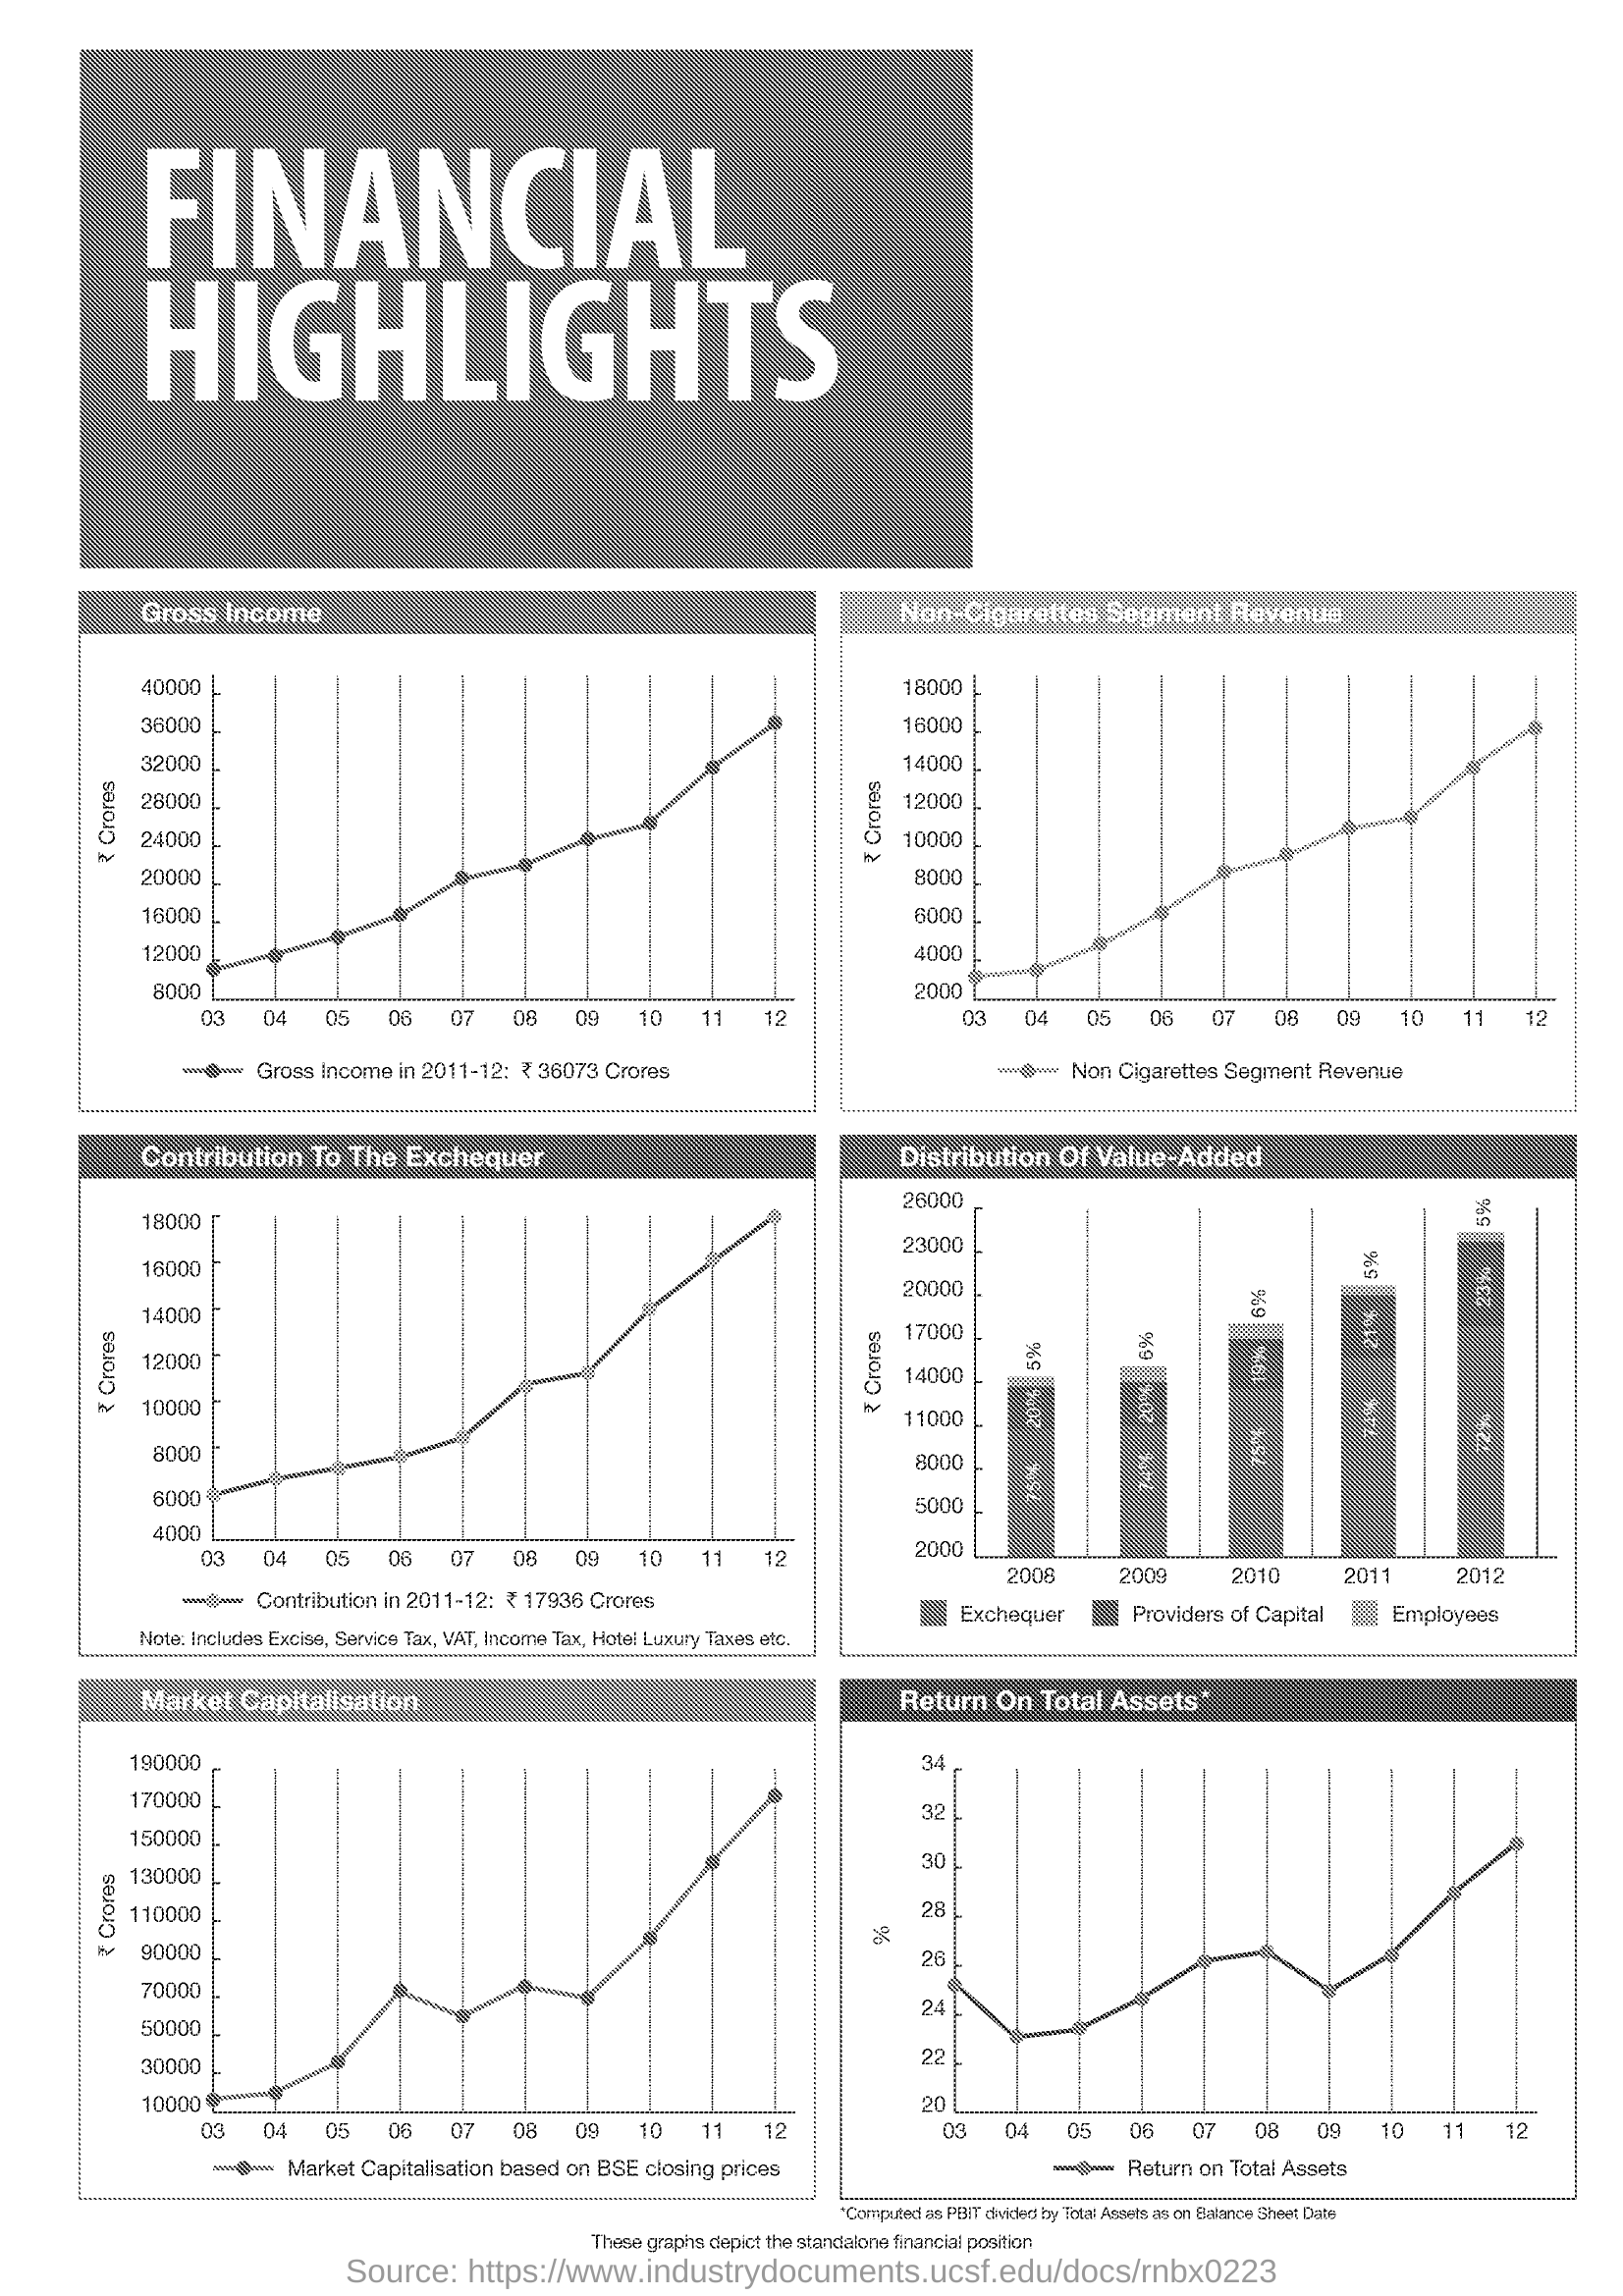

In [20]:
sample = dataset['test'][7]
image = sample["image"]
image

### Inference

In [26]:
query = "Что изображено на картинке?"
result = ru_inference(image, query, debug=True)

print(f"Question: {query}")
print(f"Answer: {result}")

Question (RU): Что изображено на картинке?
Question (EN): What is shown in the picture?


[W1112 00:55:39.305975842 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


Predicted start_idx: 8, end_idx: 0
Start token: [SEP]
End token: [CLS]
Swapping indices: start 8 > end 0
Model predicted special token, using fallback message
Answer (EN): I cannot find the answer in the document.
Answer (RU): Я не могу найти ответ в документе.
Question: Что изображено на картинке?
Answer: Я не могу найти ответ в документе.


#### Промежуточный вывод:

После нескольких запусков стало понятно, что модель недообучена.
Надо возвращаться к 1-ой части ДЗ и дообучать.

```text
Question (RU): Что изображено на картинке?
Question (EN): What is shown in the picture?
[W1112 00:55:39.305975842 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
Predicted start_idx: 8, end_idx: 0
Start token: [SEP]
End token: [CLS]
Swapping indices: start 8 > end 0
Model predicted special token, using fallback message
Answer (EN): I cannot find the answer in the document.
Answer (RU): Я не могу найти ответ в документе.
Question: Что изображено на картинке?
Answer: Я не могу найти ответ в документе.
```

In [27]:
# Тестирование на нескольких примерах из датасета
import random

print("=== Testing with multiple examples from dataset ===\n")

# Возьмем несколько случайных примеров
test_indices = random.sample(range(len(dataset['test'])), 3)

for idx in test_indices:
    sample = dataset['test'][idx]
    image = sample["image"]
    original_question = sample["question"]
    
    print(f"\n{'='*60}")
    print(f"Example {idx}:")
    print(f"Original question (EN): {original_question}")
    print(f"Expected answer: {sample['answers']}")
    print(f"\nTesting with Russian translation of the question...")
    
    # Переводим оригинальный вопрос на русский для теста
    question_ru = translate_en2ru(original_question)
    
    # Запускаем inference
    result = ru_inference(image, question_ru, debug=False)
    print(f"\nFinal answer (RU): {result}")
    print(f"{'='*60}\n")

=== Testing with multiple examples from dataset ===


Example 24:
Original question (EN): What is the title of the document?
Expected answer: None

Testing with Russian translation of the question...
Question (RU): Как называется этот документ?
Question (EN): What is the title of this document?


[W1112 00:58:04.339359250 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


Answer (EN): I cannot find the answer in the document.
Answer (RU): Я не могу найти ответ в документе.

Final answer (RU): Я не могу найти ответ в документе.


Example 2866:
Original question (EN): What is the unit in which DOSAGE (on the X axis) is plotted ?
Expected answer: None

Testing with Russian translation of the question...
Question (RU): Что представляет собой единица, в которой наносится ДССАЖ (по оси Х)?
Question (EN): What is the unit in which the LTAQ (X axis) is applied?


[W1112 00:58:08.316170095 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


Answer (EN): I cannot find the answer in the document.
Answer (RU): Я не могу найти ответ в документе.

Final answer (RU): Я не могу найти ответ в документе.


Example 828:
Original question (EN): What date is given on the top of the document?
Expected answer: None

Testing with Russian translation of the question...
Question (RU): Какая дата указана на верхней части документа?
Question (EN): What date is indicated at the top of the document?


[W1112 00:58:11.175865575 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.


Answer (EN): 1
Answer (RU): 1

Final answer (RU): 1



### [2 балла] Сделать демо на gradio

Модель готова! Теперь было бы круто, если модель можно было захостить и оттестировать на практике. В этом задании вам нужно будет реализовать демо на gradio, которое будет принимать изображение и вопрос, а далее выдавать ответ. Пример демо, аналогично которому вам нужно реализовать модель: https://huggingface.co/spaces/nielsr/comparing-VQA-models.


**Подсказка:** во вкладке `Files` на демо вы можете посмотреть реализацию, там нужно заменить инференс, используемой модели, на инференс нашей модели с переводом


**Ожидаемый результат.** В качестве результата в этой секции вам нужно код для запуска демо на градио и видеозапись его работы, где реализован описанный выше функционал. Видео прикрепляйте отдельным файлом.

In [ ]:
# TODO Реализация демо на gradio

### [4 балла] Ответы на вопросы голосом

Демо готово! Но кто хочет писать вопросы текстом?
Здесь вам предстоить улучшить ваше демо, чтобы оно могло принимать вопросы голосом. За основу вам предлагается рассмотреть демо https://www.gradio.app/guides/real-time-speech-recognition и добавить соответствуещее окошко в ваше демо. Также вы можете добавить text-to-speech модель, чтобы оно озвучило текстовый ответ (дополнительный балл к оценке).

---

**Ожидаемый результат.** В качестве результата в этой секции вам нужно код для запуска демо на градио и видеозапись его работы, где реализован описанный выше функционал.

In [ ]:
# TODO Реализация демо на gradio с голосовым вводом